In [1]:
import os
from pathlib import Path
from PIL import Image
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import tqdm

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    for i in range(torch.cuda.device_count()):
        device_name = torch.cuda.get_device_name(i) 
        print(f"Device {i} name: {device_name}")
else:
    print("CUDA not available!")

Device 0 name: NVIDIA GeForce RTX 4090
Device 1 name: NVIDIA GeForce RTX 4090


In [3]:
df = pd.read_csv("/home/karthik/Projects/Barretts_Algorithm/HRME_image_annotations_dataset.csv")

In [4]:
img_filepath = df.loc[0, "Lesion_HRME_Image_Filepath"]
mask_filepath = df.loc[0, "Lesion_HRME_Mask_Filepath"]
img = Image.open(img_filepath)
mask = Image.open(mask_filepath).convert("L")
black_image = Image.new("RGB", img.size, (0, 0, 0))
result = Image.composite(img, black_image, mask)
result

FileNotFoundError: [Errno 2] No such file or directory: '/home/karthik/lab_server_mnt/RRK_Rice_2016/users/golik/Barretts_Algorithm_Project/H-48152_Lesion_Data/B005/B005 Images/Representative_Images/B005_image1_14301_10.png'

In [5]:
# class HRMECenterCrop:
#     def __init__(self, output_size):
#         assert isinstance(output_size, (int, tuple))
#         if isinstance(output_size, int):
#             self.output_size = (output_size, output_size)
#         else:
#             assert len(output_size) == 2
#             self.output_size = output_size
        

In [6]:
class BarrettsHRMEDataset(Dataset):
    def __init__(self, annotations_csv_filepath: Path, data_partition: str = "train"):
        annotations_df = pd.read_csv(annotations_csv_filepath)
        self.transforms = transforms.Compose([transforms.Resize(224),
                                              transforms.ToTensor(),
                                              transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                                                                   std=[0.229, 0.224, 0.225])])
        
        splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
        for train_idx, test_idx in splitter.split(annotations_df, 
                                                  groups=annotations_df['Subject_ID'], 
                                                  y=annotations_df['Local_Pathology_Final']):
            self.annotations_df_train = annotations_df.iloc[train_idx].reset_index(drop=True)
            self.annotations_df_test = annotations_df.iloc[test_idx].reset_index(drop=True)
        
        self.data_partition = data_partition

    def __len__(self):
        if self.data_partition=="train":
            return len(self.annotations_df_train)
        elif self.data_partition=="test":
            return len(self.annotations_df_test)
    
    def __getitem__(self, idx):
        if self.data_partition=="train":
            img_filepath = self.annotations_df_train.loc[idx, "Lesion_HRME_Image_Filepath"]
            mask_filepath = self.annotations_df_train.loc[idx, "Lesion_HRME_Mask_Filepath"]

            img = Image.open(img_filepath).convert("RGB")
            mask = Image.open(mask_filepath).convert("L")
            zeros = Image.new("RGB", img.size, (0, 0, 0))
            img = Image.composite(img, zeros, mask)
            
            img = self.transforms(img)

            label = torch.tensor(self.annotations_df_train.loc[idx, "Local_Pathology_Final"])
        
        elif self.data_partition=="test":
            img_filepath = self.annotations_df_test.loc[idx, "Lesion_HRME_Image_Filepath"]
            img = Image.open(img_filepath).convert("RGB")
            img = self.transforms(img)

            label = torch.tensor(self.annotations_df_test.loc[idx, "Local_Pathology_Final"])

        return img, label
    
def create_dataloader(dataset: BarrettsHRMEDataset, batch_size: int = 4):
    if dataset.data_partition=="train":
        class_counts = torch.bincount(torch.tensor(dataset.annotations_df_train["Local_Pathology_Final"].values))
        class_weights = 1.0/class_counts.float()
        sample_weights = class_weights[torch.tensor(dataset.annotations_df_train["Local_Pathology_Final"].values)]
        sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
        dataloader = DataLoader(dataset=dataset, batch_size=batch_size, sampler=sampler, num_workers=0)

    elif dataset.data_partition=="test":
        dataloader = DataLoader(dataset=dataset, batch_size=batch_size, num_workers=0)
    
    return dataloader

In [7]:
train_dataset = BarrettsHRMEDataset(Path("./HRME_image_annotations_dataset.csv"), "train")
train_dataloader = create_dataloader(train_dataset)

test_dataset = BarrettsHRMEDataset(Path("./HRME_image_annotations_dataset.csv"), "test")
test_dataloader = create_dataloader(test_dataset)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


Feature batch shape: torch.Size([4, 3, 224, 298])
Labels batch shape: torch.Size([4])


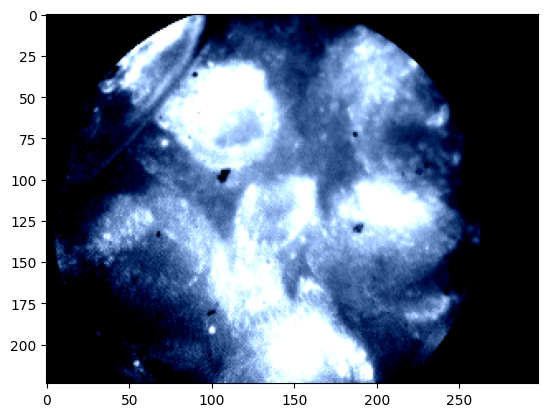

Label: 0


In [9]:
train_imgs, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_imgs.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_imgs[0].permute(1, 2, 0)
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

In [10]:
model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet152', pretrained=True)
num_ftrs = model.fc.in_features  # Get the input features of the last fully connected layer
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),  # Add a hidden layer for better generalization
    nn.ReLU(),
    nn.Dropout(0.5),  # Add dropout to prevent overfitting
    nn.Linear(512, 1),  # Output layer with a single unit for binary classification
    nn.Sigmoid()  # Sigmoid activation for binary classification (output between 0 and 1)
)
model = model.to(device)

Using cache found in /home/karthik/.cache/torch/hub/pytorch_vision_v0.10.0
/home/karthik/anaconda3/envs/barretts_algo_env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/karthik/anaconda3/envs/barretts_algo_env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet152_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet152_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [11]:
train_imgs = train_imgs.to(device)
with torch.no_grad():
    output = model(train_imgs)
output

tensor([[0.5275],
        [0.4854],
        [0.4859],
        [0.4629]], device='cuda:0')

In [12]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

In [13]:
def plot_roc_curves(y_true, y_pred):
    fpr, tpr, thresh = roc_curve(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'Model {auc:.2f}')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)  # Diagonal line (random classifier)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('1 - Specificity')
    plt.ylabel('Sensitivity')
    plt.title(f'ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

Epoch 1/10: 100%|██████████| 22/22 [00:05<00:00,  3.92batch/s]


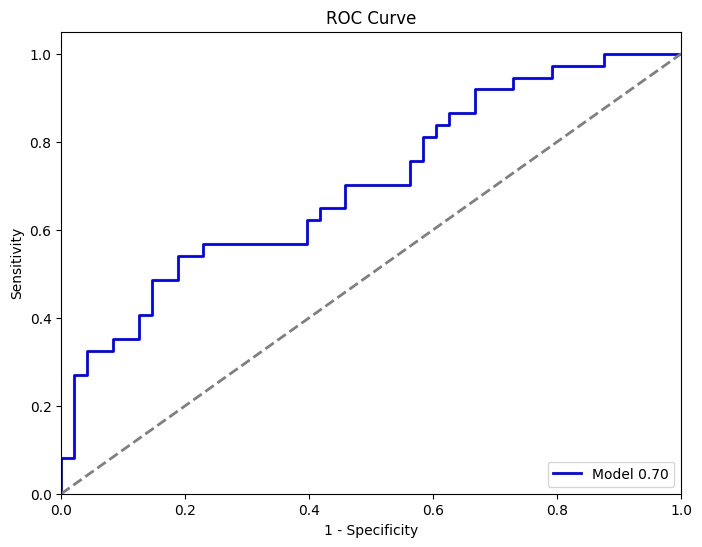

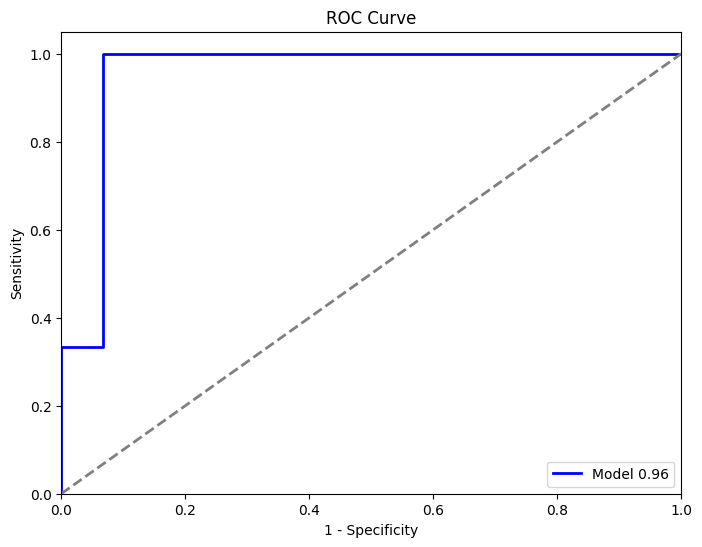

Train loss: 0.6584262576970187 Train accuracy: 0.6588235294117647


Epoch 2/10: 100%|██████████| 22/22 [00:03<00:00,  7.25batch/s]


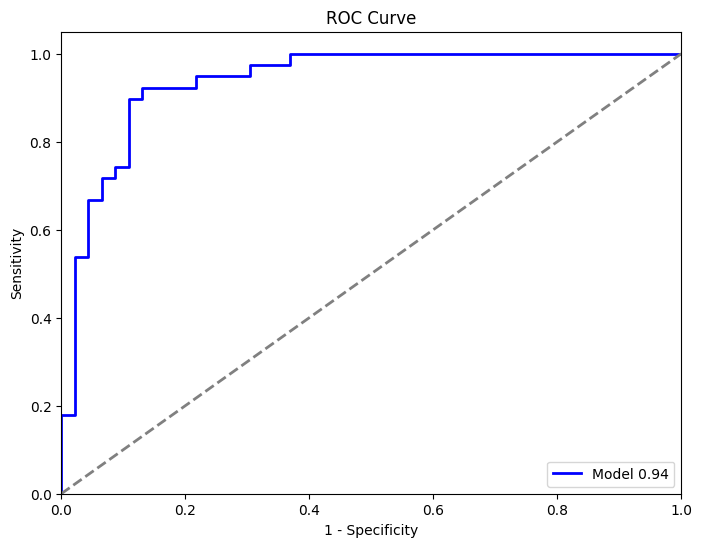

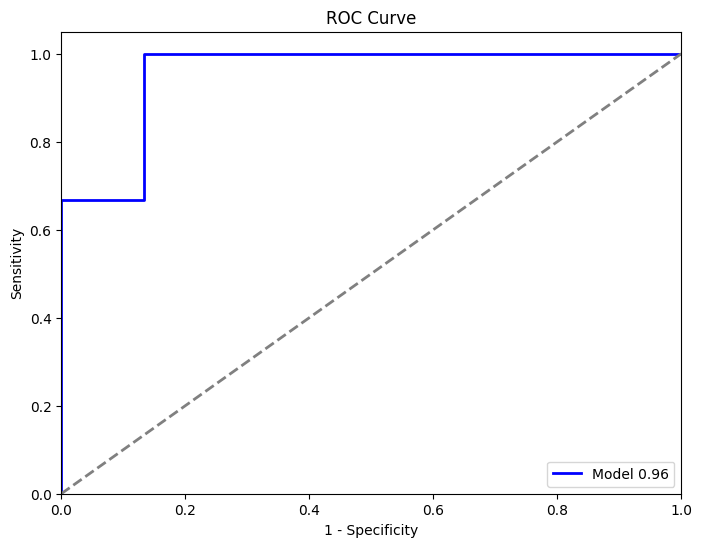

Train loss: 0.5768427306955511 Train accuracy: 0.7764705882352941


Epoch 3/10: 100%|██████████| 22/22 [00:02<00:00,  9.92batch/s]


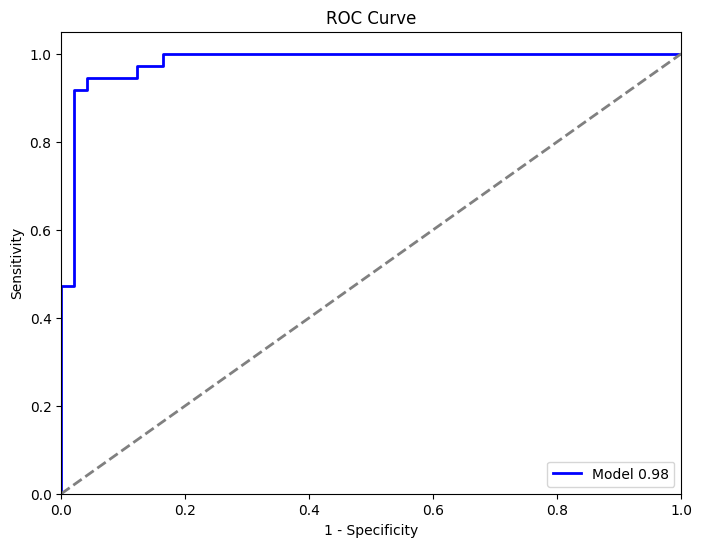

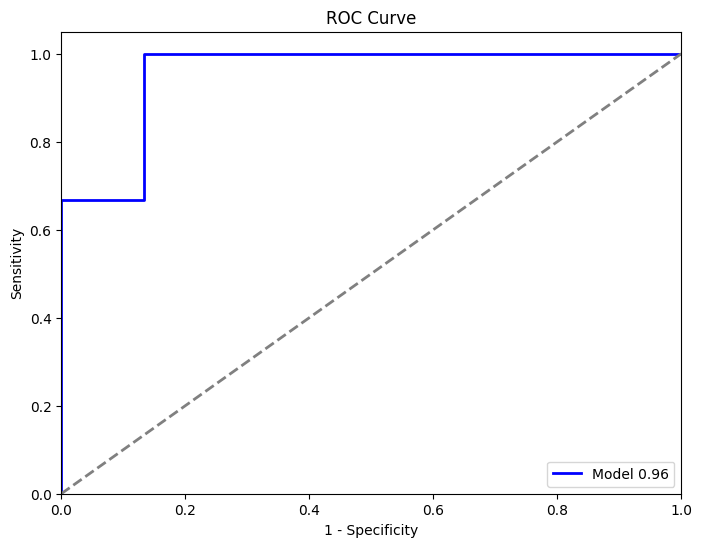

Train loss: 0.4733848382126201 Train accuracy: 0.8705882352941177


Epoch 4/10: 100%|██████████| 22/22 [00:02<00:00, 10.37batch/s]


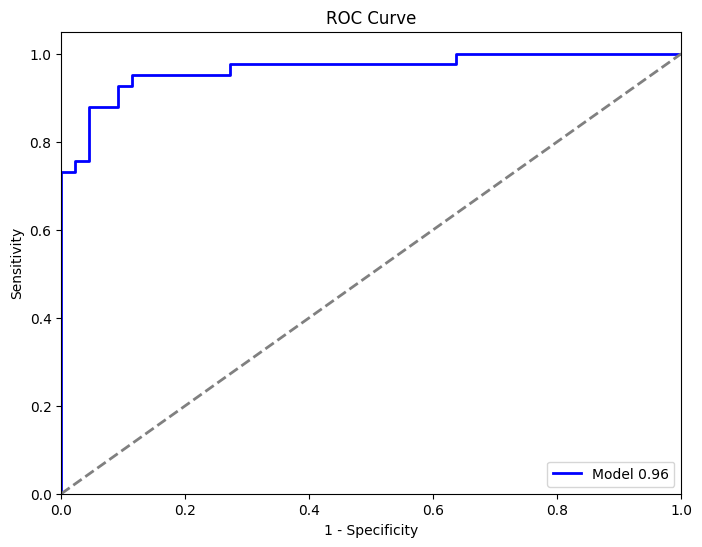

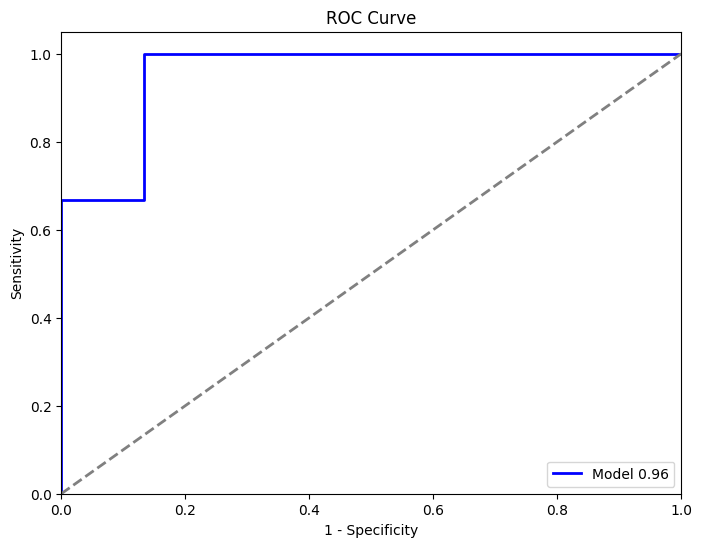

Train loss: 0.4372077218510888 Train accuracy: 0.8823529411764706


Epoch 5/10: 100%|██████████| 22/22 [00:01<00:00, 11.33batch/s]


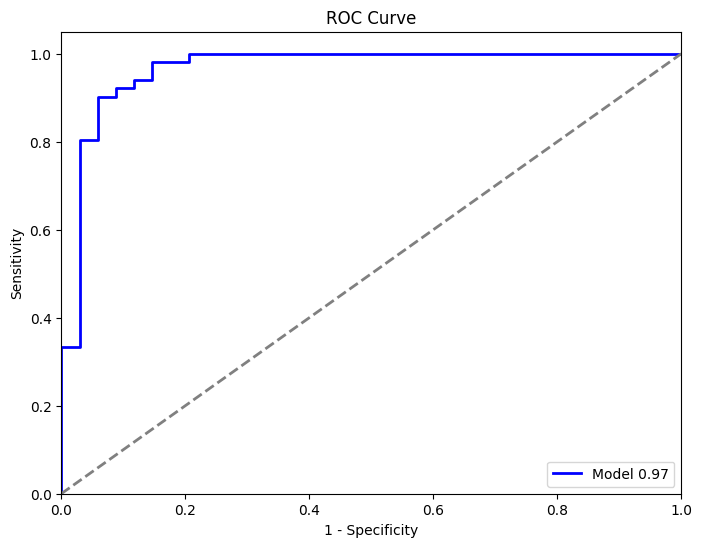

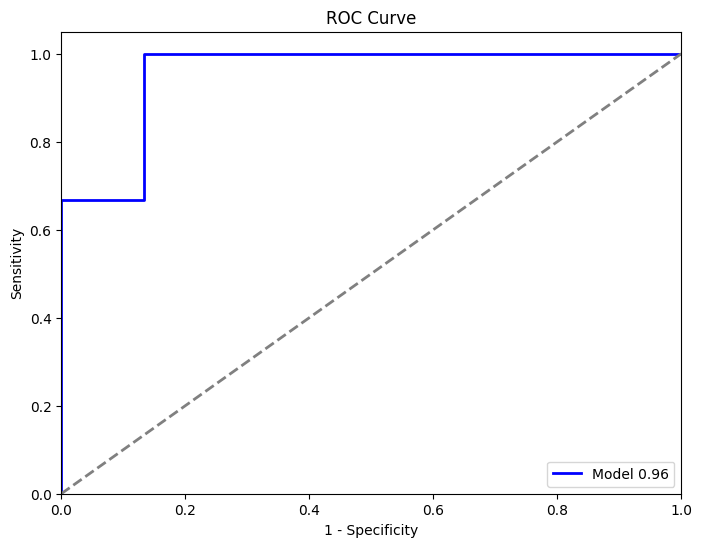

Train loss: 0.41315711357376794 Train accuracy: 0.8705882352941177


Epoch 6/10: 100%|██████████| 22/22 [00:01<00:00, 12.17batch/s]


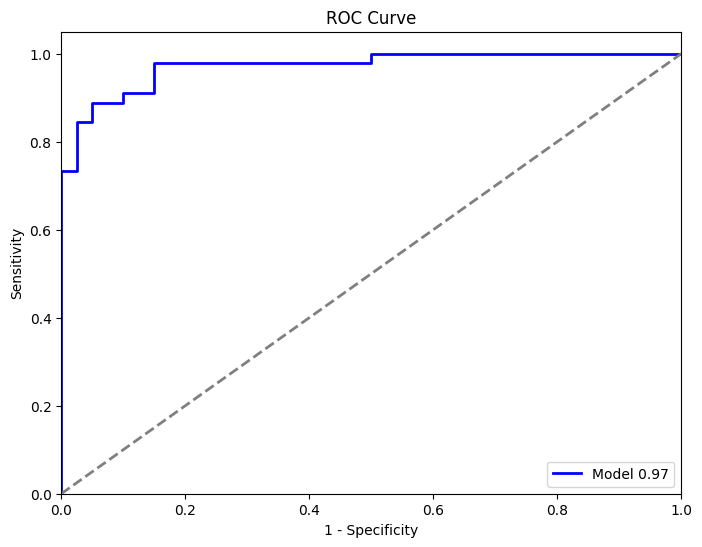

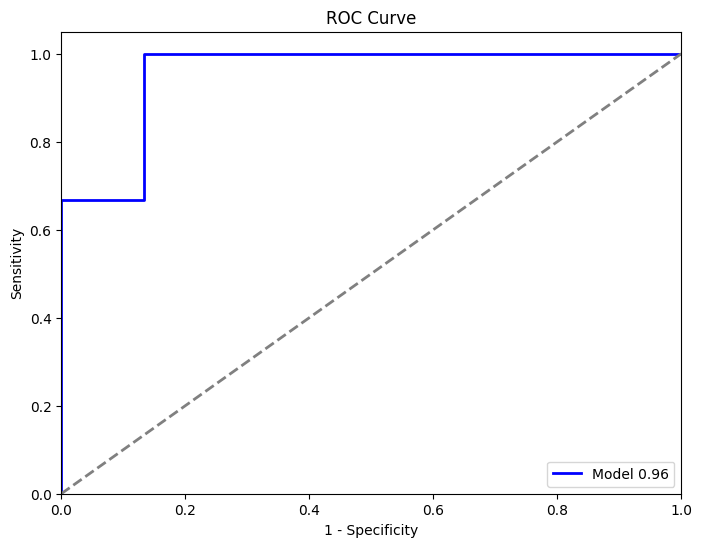

Train loss: 0.3270963037555868 Train accuracy: 0.8941176470588236


Epoch 7/10: 100%|██████████| 22/22 [00:01<00:00, 11.10batch/s]


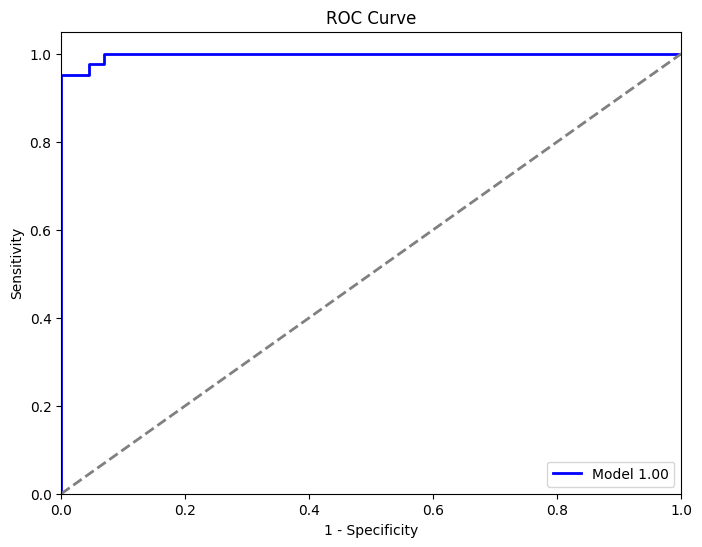

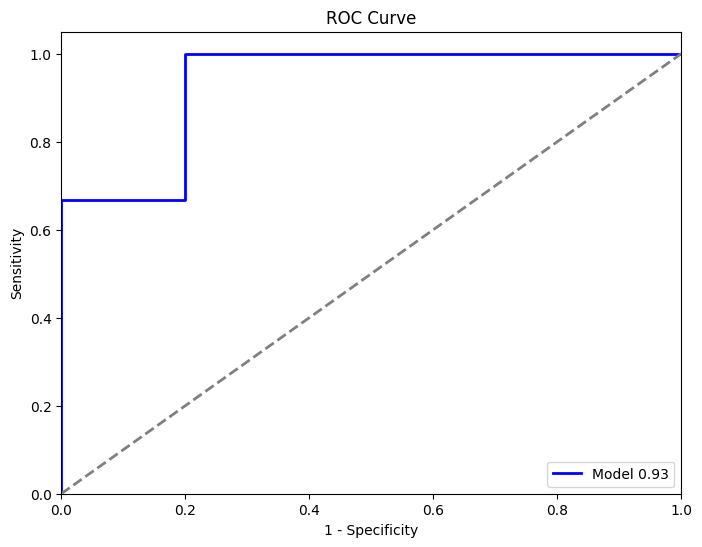

Train loss: 0.22774309529499573 Train accuracy: 0.9764705882352941


Epoch 8/10: 100%|██████████| 22/22 [00:01<00:00, 12.23batch/s]


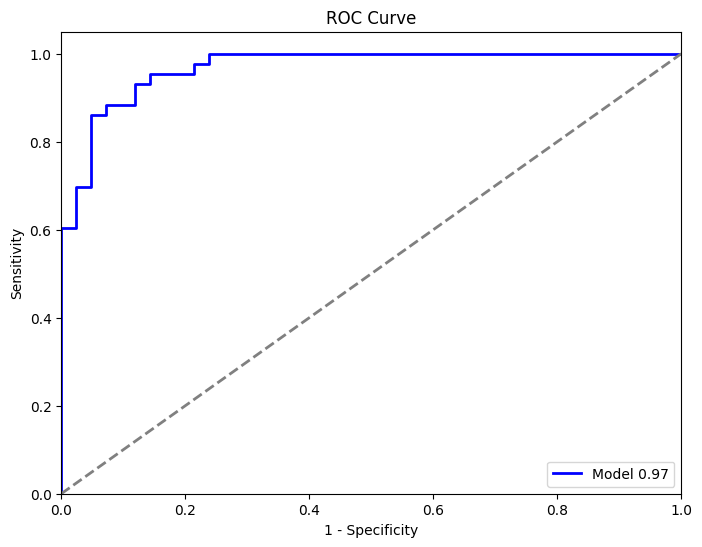

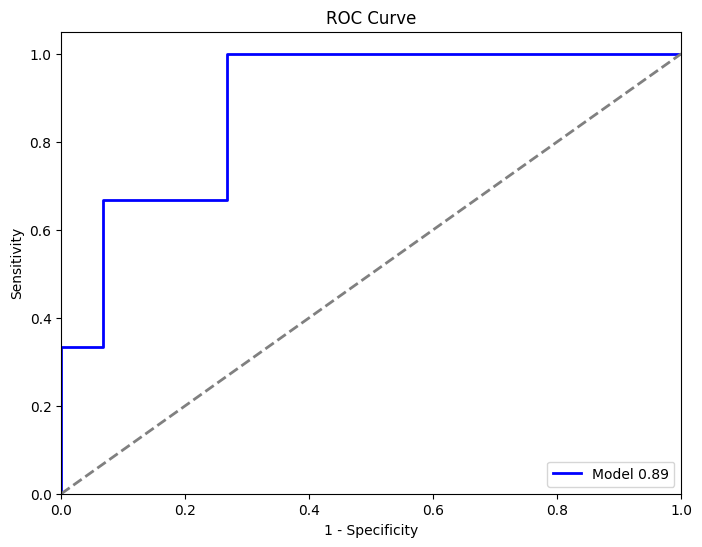

Train loss: 0.2978532368486578 Train accuracy: 0.8823529411764706


Epoch 9/10: 100%|██████████| 22/22 [00:01<00:00, 12.73batch/s]


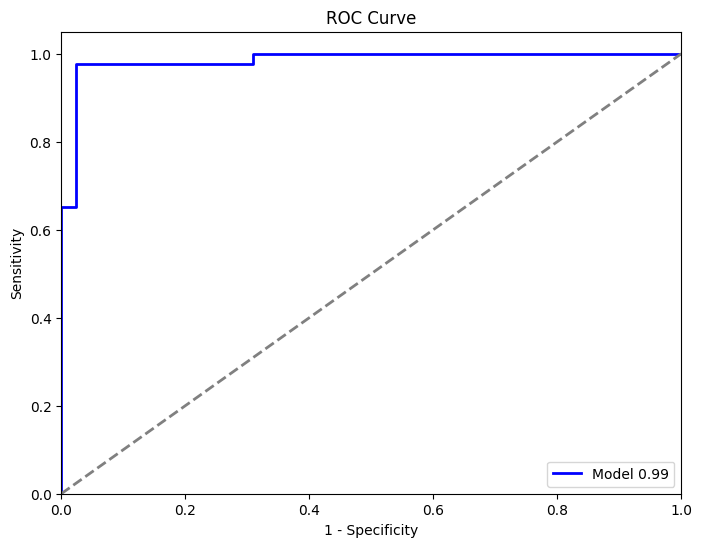

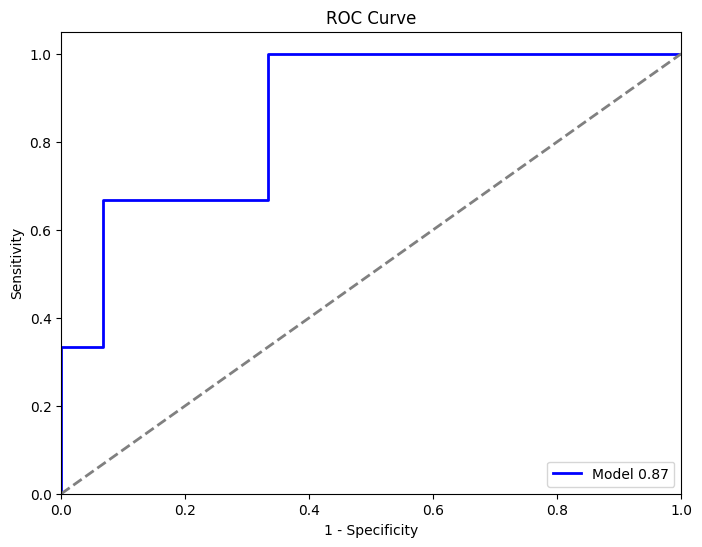

Train loss: 0.20223924060436813 Train accuracy: 0.9647058823529412


Epoch 10/10: 100%|██████████| 22/22 [00:01<00:00, 11.95batch/s]


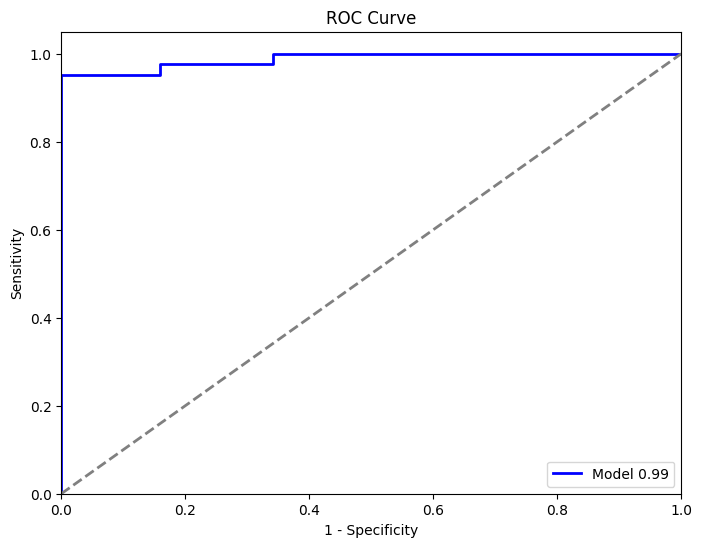

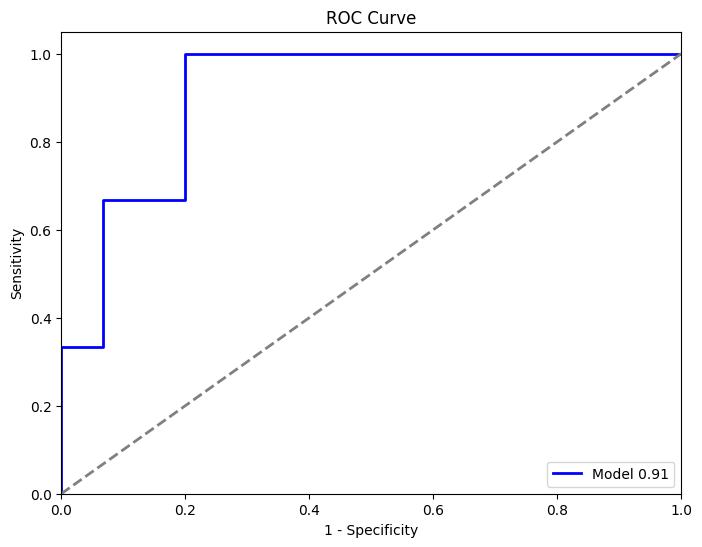

Train loss: 0.20004193247719246 Train accuracy: 0.9647058823529412


In [14]:
num_epochs = 10  # Adjust based on your dataset size
best_accuracy = 0.0
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    gt_train = []
    pred_train = []

    # Iterate through the training data
    for inputs, labels in tqdm.tqdm(train_dataloader, desc=f'Epoch {epoch + 1}/{num_epochs}', unit='batch'):
        gt_train += labels.numpy().tolist()
        inputs, labels = inputs.to(device), labels.to(device).float()

        # Forward pass
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs.squeeze(1), labels)  # Squeeze to remove extra dimension for binary classification

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Calculate accuracy
        predicted = (outputs.squeeze() > 0.5).float()  # Threshold at 0.5 for binary classification
        correct_predictions += (predicted == labels).sum().item()
        total_samples += labels.size(0)

        pred_train += outputs.detach().cpu().numpy().tolist()
    
    plot_roc_curves(gt_train, pred_train)


    pred_test = []
    gt_test = []
    model.eval()
    with torch.no_grad():
        for inputs, labels in test_dataloader:
            inputs, labels = inputs.to(device), labels.to(device).float()
            outputs = model(inputs)
            pred_test += outputs.squeeze(1).cpu().numpy().tolist()
            gt_test += labels.cpu().numpy().tolist()
    plot_roc_curves(gt_test, pred_test)

    # Calculate training loss and accuracy
    train_loss = running_loss / len(train_dataloader)
    train_accuracy = correct_predictions / total_samples
    print("Train loss:", train_loss, "Train accuracy:", train_accuracy)

In [16]:
np.unique(df["Subject_ID"]).shape

(24,)

In [28]:
df["Unique_Lesion_ID"] = df["Subject_ID"] + df["Lesion_#"].astype(str)
df["Unique_Image_ID"] = df["Subject_ID"] + df["Lesion_HRME_Image"].astype(str)

In [29]:
np.unique(df["Unique_Lesion_ID"]).shape

(71,)

In [30]:
np.unique(df["Unique_Image_ID"]).shape

(103,)

In [31]:
df["Local_Pathology_Final"].value_counts()

Local_Pathology_Final
0    85
1    18
Name: count, dtype: int64

In [42]:
df[df["Local_Pathology_Final"]==0]["Lesion_HRME_Image_Filepath"].to_numpy()[20]

'/home/karthik/lab_server_mnt/RRK_Rice_2016/users/golik/Barretts_Algorithm_Project/H-48152_Lesion_Data/B023/Representative_Images/image3_14298_19.png'